In [ ]:
import zipfile
import os

# Define the path to the zip file
zip_path = "/content/archive (8).zip"
extract_path = "/content/archive8_extracted"

# Create directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Files extracted to: {extract_path}")

Files extracted to: /content/archive8_extracted


In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import os, cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pylab import rcParams
rcParams['figure.figsize'] = 20, 10

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from keras.metrics import categorical_accuracy
from keras.models import model_from_json
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.optimizers import *


# Unzip the file first
import zipfile

zip_path = "/content/archive (8).zip"
extract_path = "/content/archive8_extracted"

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Print the list of files/folders extracted
print("Extracted files:")
print(os.listdir(extract_path))


Extracted files:
['CK+48']


In [ ]:
# Path to the extracted folder inside /content
data_path = '/content/archive8_extracted/CK+48'  # Adjust this if CK+48 is in a subfolder
data_dir_list = os.listdir(data_path)

num_epoch = 10
img_data_list = []

for dataset in data_dir_list:
    img_list = os.listdir(os.path.join(data_path, dataset))
    print(f'Loaded the images of dataset - {dataset}\n')

    for img in img_list:
        img_path = os.path.join(data_path, dataset, img)
        input_img = cv2.imread(img_path)

        if input_img is None:
            print(f"Could not read image: {img_path}")
            continue

        input_img_resize = cv2.resize(input_img, (48, 48))
        img_data_list.append(input_img_resize)

# Convert to NumPy array and normalize
img_data = np.array(img_data_list)
img_data = img_data.astype('float32') / 255.0
print("Shape of image data:", img_data.shape)


Loaded the images of dataset - happy

Loaded the images of dataset - surprise

Loaded the images of dataset - anger

Loaded the images of dataset - fear

Loaded the images of dataset - sadness

Shape of image data: (750, 48, 48, 3)


In [ ]:
num_classes = 7

num_of_samples = img_data.shape[0]
labels = np.ones((num_of_samples,),dtype='int64')

labels[0:134]=0 #135
labels[135:188]=1 #54
labels[189:365]=2 #177
labels[366:440]=3 #75
labels[441:647]=4 #207
labels[648:731]=5 #84
labels[732:980]=6 #249

names = ['anger','contempt','disgust','fear','happy','sadness','surprise']

def getLabel(id):
    return ['anger','contempt','disgust','fear','happy','sadness','surprise'][id]

In [ ]:
from keras.utils import to_categorical  # Make sure this is at the top

Y = to_categorical(labels, num_classes)

# Shuffle the dataset
x, y = shuffle(img_data, Y, random_state=2)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)
x_test = X_test


In [ ]:
def create_model():
    input_shape=(48,48,3)

    model = Sequential()
    model.add(Conv2D(6, (5, 5), input_shape=input_shape, padding='same', activation = 'relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(16, (5, 5), padding='same', activation = 'relu'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(64, (3, 3), activation = 'relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation = 'relu'))
    model.add(Dropout(0.5))
    model.add(Dense(7, activation = 'softmax'))

    model.compile(loss='categorical_crossentropy', metrics=['accuracy'],optimizer='RMSprop')

    return model

In [ ]:
model_custom = create_model()
model_custom.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217,983 (851.50 KB)

 Trainable params: 217,983 (851.50 KB)

 Non-trainable params: 0 (0.00 B)

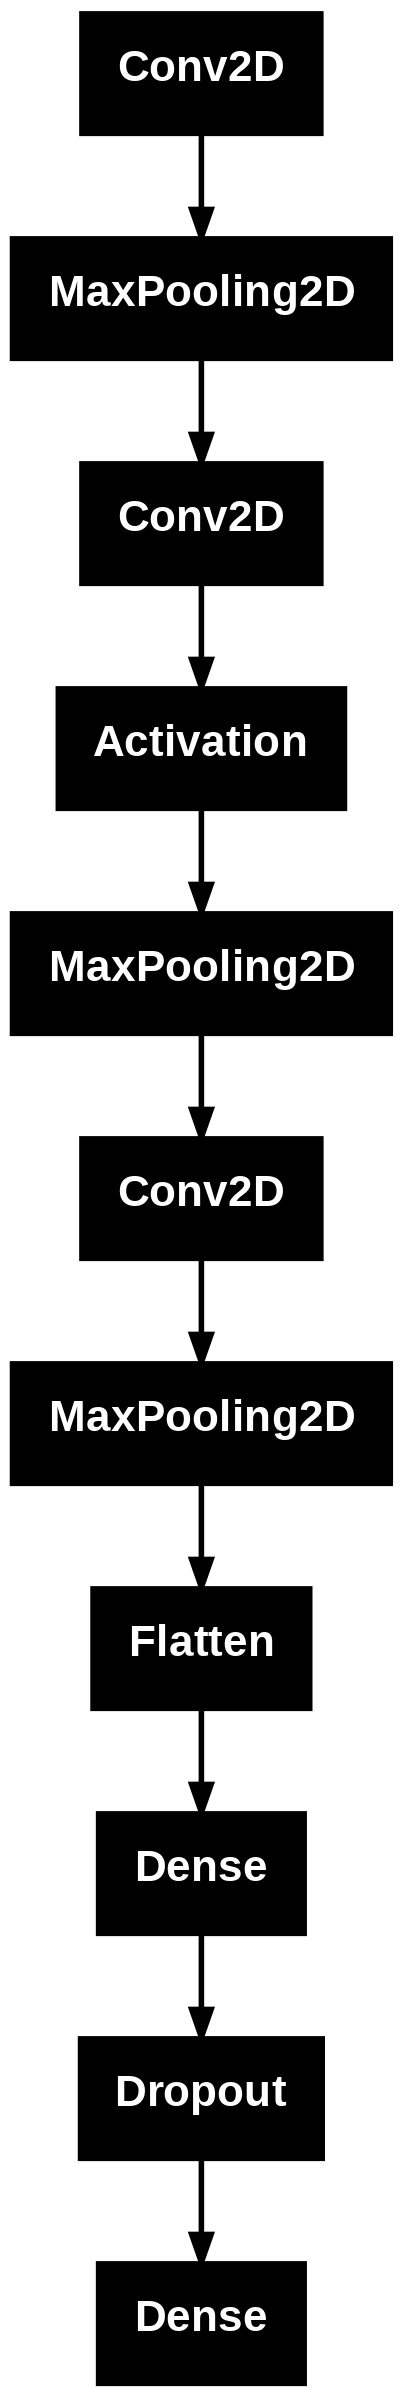

In [ ]:
from keras.utils import plot_model
plot_model(model_custom, to_file='model.png')

In [ ]:
from sklearn.model_selection import KFold

In [ ]:
kf = KFold(n_splits=5, shuffle=False)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

aug = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)


In [ ]:
BS = 8
EPOCHS = 200

In [ ]:
import os

# Define the directory where you want to save the weights
weights_dir = "/content/model_weights"
os.makedirs(weights_dir, exist_ok=True)

k_no = 1  # or any other relevant integer value representing the fold number

# Now you can use weights_dir and k_no in your code
file_path = os.path.join(weights_dir, f"weights_best_{k_no}.keras")

In [ ]:
file_path = os.path.join(weights_dir, f"weights_best_{k_no}.keras")


In [ ]:
!pip install --upgrade tensorflow


In [ ]:
import os
import zipfile
from google.colab import files

# Step 1: Upload the zip file
print("📁 Please upload your ZIP file (e.g., archive.zip):")
uploaded = files.upload()

# Step 2: Get the filename from uploaded
zip_filename = list(uploaded.keys())[0]  # Automatically use the uploaded file
extract_dir = "/content/dataset"

# Step 3: Extract the zip file
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Step 4: Print directory structure
print("\n📂 Extracted Directory Structure:")
for root, dirs, files in os.walk(extract_dir):
    print("ROOT:", root)
    print("DIRS:", dirs)
    print("FILES:", files)
    print("=" * 40)


📁 Please upload your ZIP file (e.g., archive.zip):


Saving archive (8).zip to archive (8) (1).zip

📂 Extracted Directory Structure:
ROOT: /content/dataset
DIRS: ['CK+48']
FILES: []
ROOT: /content/dataset/CK+48
DIRS: ['happy', 'surprise', 'anger', 'fear', 'sadness']
FILES: []
ROOT: /content/dataset/CK+48/happy
DIRS: []
FILES: ['S093_004_00000014.png', 'S083_003_00000018.png', 'S094_004_00000012.png', 'S010_006_00000014.png', 'S079_004_00000025.png', 'S068_002_00000015.png', 'S064_003_00000024.png', 'S083_003_00000017.png', 'S072_006_00000020.png', 'S035_006_00000017.png', 'S037_006_00000021.png', 'S093_004_00000016.png', 'S011_006_00000012.png', 'S096_004_00000009.png', 'S092_004_00000022.png', 'S067_005_00000022.png', 'S065_004_00000027.png', 'S125_005_00000013.png', 'S134_004_00000013.png', 'S099_004_00000015.png', 'S075_006_00000023.png', 'S131_006_00000022.png', 'S063_002_00000023.png', 'S094_004_00000010.png', 'S086_002_00000013.png', 'S083_003_00000019.png', 'S091_003_00000019.png', 'S130_013_00000015.png', 'S014_005_00000015.png',

In [ ]:
data_dir = "/content/dataset/ACTUAL_FOLDER_NAME"


In [ ]:
import os
import numpy as np
import cv2
import zipfile
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Unzip dataset
zip_path = "/content/archive (8).zip"  # Changed to the correct zip file name
extract_dir = "/content/dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Dataset path
data_dir = "/content/dataset/CK+48"
img_size = 48



In [ ]:
import os
import numpy as np
import cv2
import zipfile
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Unzip dataset
zip_path = "/content/archive (8) (1).zip"
extract_dir = "/content/dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Dataset path
data_dir = "/content/dataset/CK+48"
img_size = 48

# Load images
x = []
y = []
class_labels = sorted(os.listdir(data_dir))
label_map = {label: i for i, label in enumerate(class_labels)}

for label in class_labels:
    label_path = os.path.join(data_dir, label)
    if not os.path.isdir(label_path):
        continue
    for img_file in os.listdir(label_path):
        img_path = os.path.join(label_path, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (img_size, img_size))
            x.append(img)
            y.append(label_map[label])

x = np.array(x).reshape(-1, img_size, img_size, 1).astype('float32') / 255.0
y = to_categorical(np.array(y))

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Data augmentation
aug = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Callbacks
os.makedirs("/content/model_weights", exist_ok=True)
file_path = "/content/model_weights/weights_best.keras"
checkpoint = ModelCheckpoint(file_path, monitor='val_loss', save_best_only=True, mode='min')
early = EarlyStopping(monitor="val_loss", mode="min", patience=6)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
callbacks_list = [checkpoint, early, lr_scheduler]

# Model architecture
def create_model():
    model = Sequential()
    model.add(Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 1)))
    model.add(MaxPooling2D(2,2))
    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(len(class_labels), activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Train the model
EPOCHS = 20
model = create_model()
model.fit(aug.flow(X_train, Y_train, batch_size=32), epochs=EPOCHS, validation_data=(X_test, Y_test), callbacks=callbacks_list, verbose=1)

# Load best weights and evaluate
model.load_weights(file_path)
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print("Final Test Accuracy:", acc)
print("Final Test Loss:", loss)


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step - accuracy: 0.3077 - loss: 1.5758 - val_accuracy: 0.2800 - val_loss: 1.5261 - learning_rate: 0.0010
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.3769 - loss: 1.4846 - val_accuracy: 0.3133 - val_loss: 1.4218 - learning_rate: 0.0010
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.4430 - loss: 1.4182 - val_accuracy: 0.5667 - val_loss: 1.2042 - learning_rate: 0.0010
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.5330 - loss: 1.2520 - val_accuracy: 0.7000 - val_loss: 0.9471 - learning_rate: 0.0010
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.5537 - loss: 1.1425 - val_accuracy: 0.6733 - val_loss: 0.8756 - learning_rate: 0.0010
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.6392 - loss: 0.9973 - val_accuracy: 0.7733 - val_loss: 0.7511 - learning_rate: 0.0010
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.6795 - loss: 0.9267 - val_accurac

In [ ]:
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print("Final Test Accuracy:", acc)
print("Final Test Loss:", loss)


Final Test Accuracy: 0.8199999928474426
Final Test Loss: 0.4184611141681671


In [ ]:
# Evaluate model
loss, acc = model.evaluate(X_test, Y_test, verbose=0)

# Print the results in full percentage
print(f" Final Test Accuracy: {acc * 100:.2f}%")
print(f" Final Test Loss: {loss:.4f}")


 Final Test Accuracy: 82.00%
 Final Test Loss: 0.4185


In [ ]:
# Assuming you have your model evaluation results stored in `loss` and `acc` variables
scores_acc = [acc]  # Store accuracy in a list
scores_loss = [loss] # Store loss in a list

print(scores_acc, scores_loss)

[0.8199999928474426] [0.4184611141681671]


In [ ]:
value_min = min(scores_loss)
value_index = scores_loss.index(value_min)
print(value_index)

0


In [ ]:
os.makedirs("/content/model_weights", exist_ok=True)

In [ ]:
# Save weights with the correct file extension
weight_path = os.path.join("/content/model_weights", f"weights_best_{k_no}.weights.h5")

model.save_weights(weight_path)  # Save the model weights with .weights.h5 extension


In [ ]:
import os
print(os.path.exists("/content/model_weights/weights_best_1.h5"))


False


In [ ]:
print(os.listdir('/content/model_weights'))


['weights_best_1.weights.h5', 'weights_best.keras']


In [ ]:
os.makedirs('/content/model_weights', exist_ok=True)


In [ ]:
weight_path = os.path.join("/content/model_weights", f"weights_best_{value_index}.h5")
print(f"Loading weights from: {weight_path}")


Loading weights from: /content/model_weights/weights_best_0.h5


In [ ]:
best_model = model


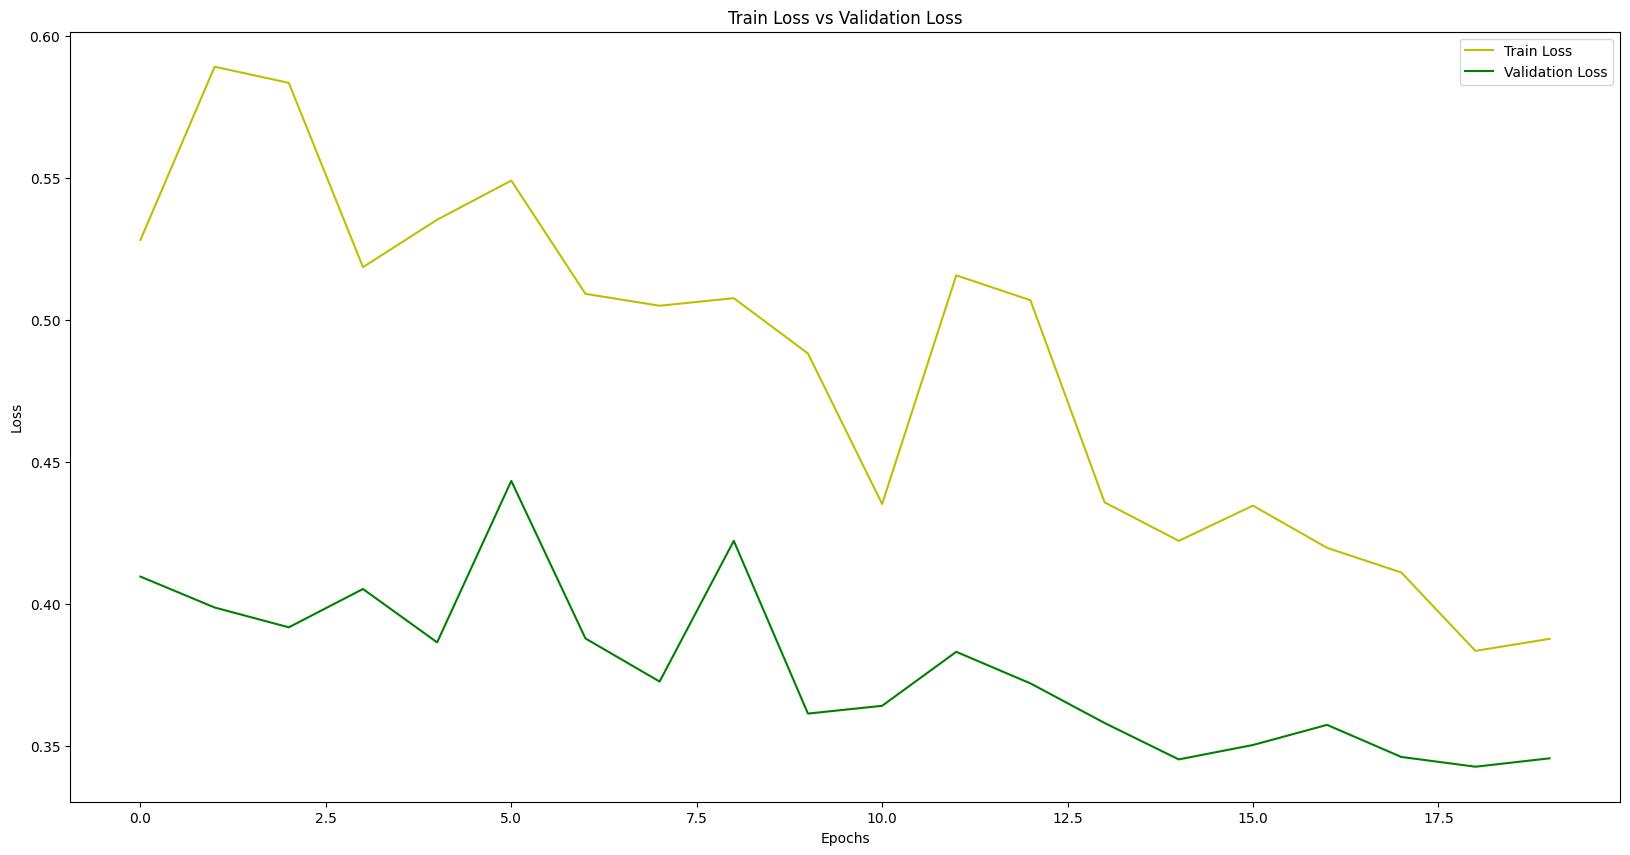

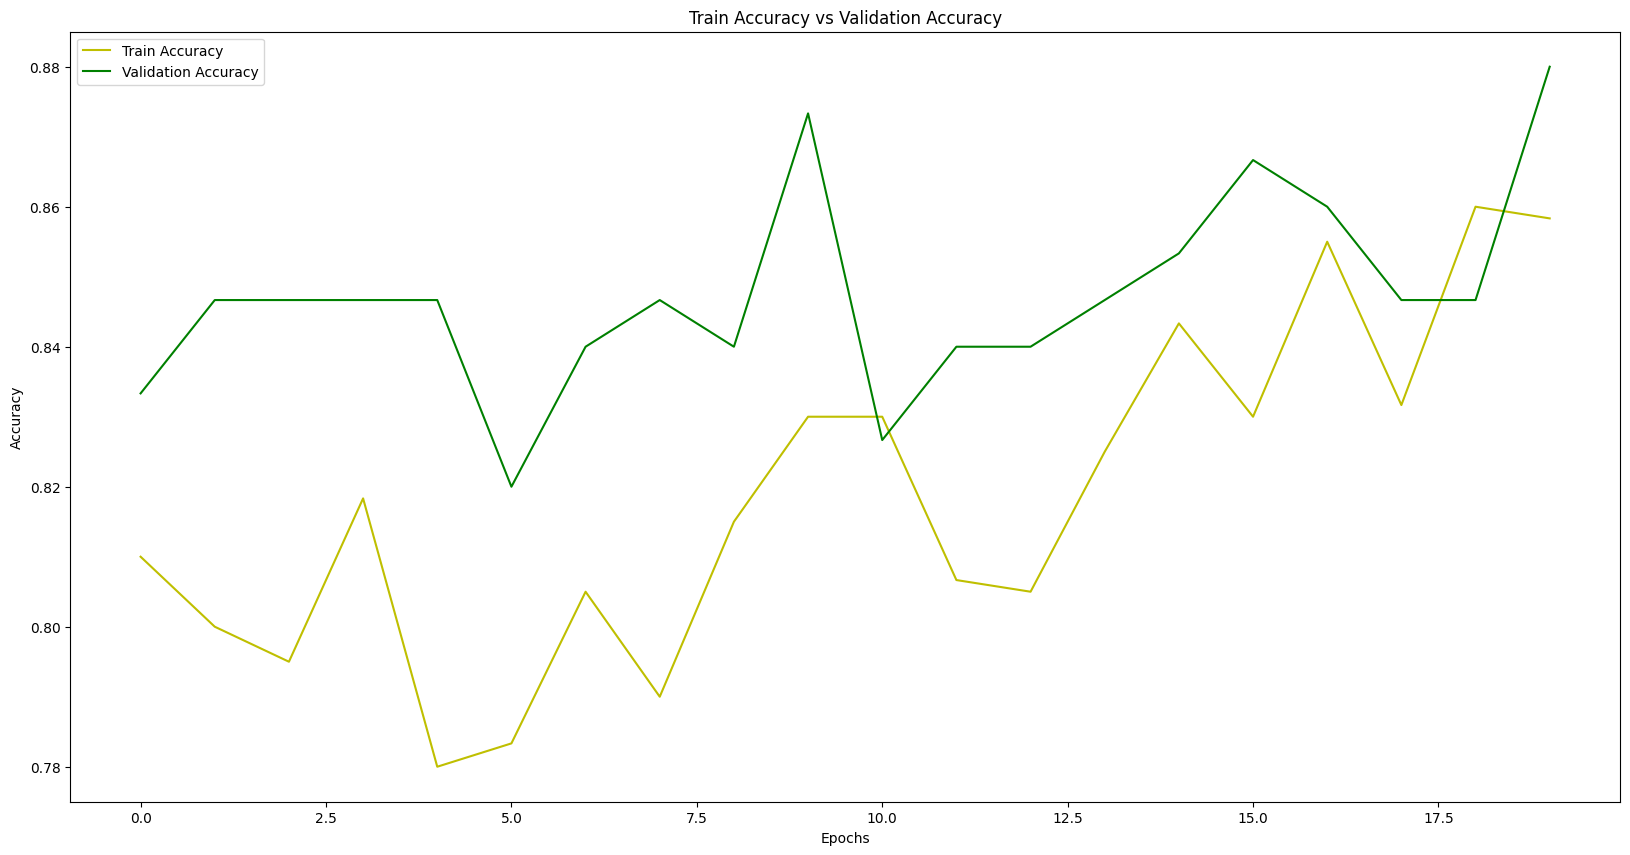

In [ ]:

# Visualize accuracy and loss
import matplotlib.pyplot as plt

train_loss = hist.history['loss']
val_loss = hist.history['val_loss']
train_acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']

epochs = range(len(train_acc))

# Plot Train vs Validation Loss
plt.plot(epochs, train_loss, 'y', label='Train Loss')
plt.plot(epochs, val_loss, 'g', label='Validation Loss')
plt.title('Train Loss vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Train vs Validation Accuracy
plt.plot(epochs, train_acc, 'y', label='Train Accuracy')
plt.plot(epochs, val_acc, 'g', label='Validation Accuracy')
plt.title('Train Accuracy vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
# Save the model after training
model_save_path = '/content/drive/MyDrive/saved_model.h5'  # Specify the path where you want to save the model
model.save(model_save_path)
print(f"Model saved to {model_save_path}")


Model saved to /content/drive/MyDrive/saved_model.h5


In [ ]:
from keras.models import load_model

# Load the saved model
loaded_model = load_model('/content/drive/MyDrive/saved_model.h5')

# Evaluate the loaded model on the test set, using X_test instead of X_Test_

loaded_model.evaluate(X_test, Y_test, verbose=1)  # Changed X_Test_ to X_test and Y_Test to y_test (lowercase)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.8741 - loss: 0.3534


[0.34575116634368896, 0.8799999952316284]

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get model predictions
y_pred = model.predict(X_test)  # Changed X_Test_ to X_test
y_pred_classes = y_pred.argmax(axis=1)  # Convert probabilities to class labels

# Assuming Y_test is one-hot encoded, so convert it to class labels as well
y_true = Y_test.argmax(axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Confusion Matrix:
[[29  0  0  2  0]
 [ 0  7  1  0  1]
 [ 0  0 47  0  0]
 [10  2  0  9  0]
 [ 0  0  2  0 40]]


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Confusion Matrix:
[[29  0  0  2  0]
 [ 0  7  1  0  1]
 [ 0  0 47  0  0]
 [10  2  0  9  0]
 [ 0  0  2  0 40]]


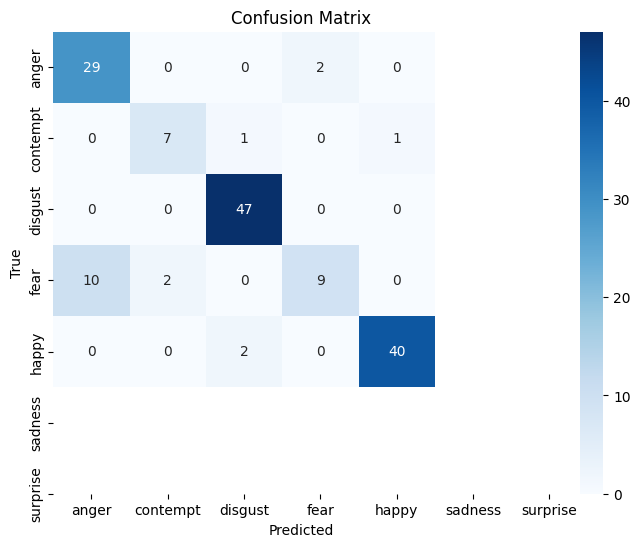

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


# Get model predictions
y_pred = model.predict(X_test)  # Changed X_Test_ to X_test
y_pred_classes = y_pred.argmax(axis=1)  # Convert probabilities to class labels

y_true = Y_test.argmax(axis=1)  # Changed Y_Test to Y_test

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Define class_names here (replace with your actual class names)
class_names = ['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']

# Plot confusion matrix using heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
import seaborn as sns
import pandas as pd

In [ ]:
label_mapdisgust = ['anger','contempt','disgust','fear','happy','sadness','surprise']

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get model predictions

y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

# Convert Y_test to class labels

y_true = Y_test.argmax(axis=1)

# Compute confusion matrix

cm = confusion_matrix(y_true, y_pred_classes)

# Print confusion matrix

print("Confusion Matrix:")
print(cm)

# Get the unique class labels from the predictions and true labels

unique_labels = sorted(list(set(y_true) | set(y_pred_classes)))

#unique_labels = np.unique(np.concatenate((y_true, y_pred_classes)))

# Filter class_names to match unique_labels
class_names_filtered = [class_names[i] for i in unique_labels]

# Create a pandas DataFrame from the confusion matrix using filtered class names
cm_df = pd.DataFrame(cm, index=class_names_filtered, columns=class_names_filtered)

# Now you can use cm_df for further analysis and visualization
final_cm = cm_df


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Confusion Matrix:
[[29  0  0  2  0]
 [ 0  7  1  0  1]
 [ 0  0 47  0  0]
 [10  2  0  9  0]
 [ 0  0  2  0 40]]


In [ ]:
final_cm


,anger,contempt,disgust,fear,happy
anger,29,0,0,2,0
contempt,0,7,1,0,1
disgust,0,0,47,0,0
fear,10,2,0,9,0
happy,0,0,2,0,40


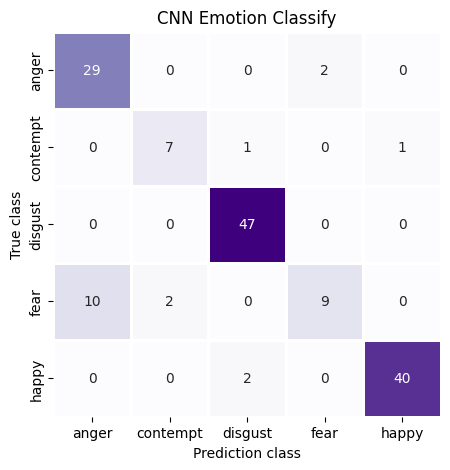

In [ ]:
plt.figure(figsize = (5,5))
sns.heatmap(final_cm, annot=True, cmap='Purples', cbar=False, linewidth=2, fmt='d')  # Change cmap here
plt.title('CNN Emotion Classify')
plt.ylabel('True class')
plt.xlabel('Prediction class')
plt.show()


In [ ]:
from sklearn.metrics import roc_curve,auc
from itertools import cycle

In [ ]:
new_label = ['anger','contempt','disgust','fear','happy','sadness','surprise']
final_label = new_label
new_class = 7

In [ ]:
#ravel flatten the array into single vector
y_pred_ravel = y_pred.ravel()
lw = 2

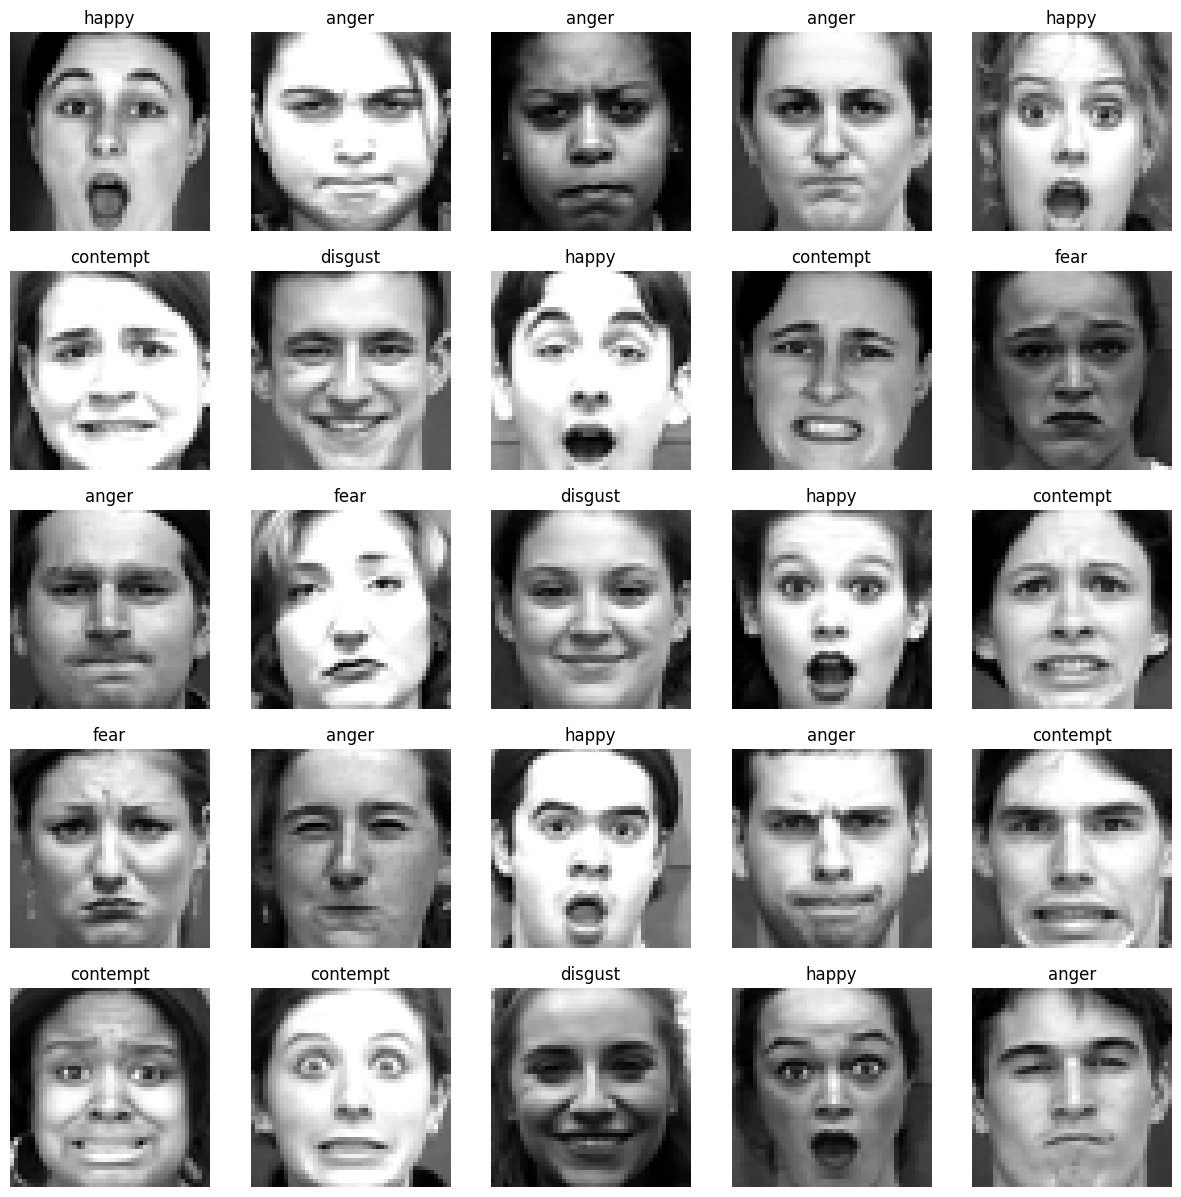

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img  # Import load_img
import numpy as np

# Create a list to hold file paths and labels
files_and_labels = []

# Loop through a sample of the training data (X_train, Y_train)
num_samples_to_display = 25
for i in range(min(num_samples_to_display, len(X_train))):
    # Assuming X_train contains image data and Y_train contains labels
    image_data = X_train[i]  # Get image data
    label_index = np.argmax(Y_train[i])  # Get label index
    label = class_names[label_index]  # Get label name

    # If X_train contains file paths:
    # img = load_img(image_data)

    files_and_labels.append((image_data, label))  # Add file path and label

# Plot the sample images
plt.figure(figsize=(15, 15))
for i, (image_data, label) in enumerate(files_and_labels):
    plt.subplot(5, 5, i + 1)
    # If X_train contains image data:
    plt.imshow(image_data.squeeze(), cmap='gray')  # Display image (assuming grayscale)
    # If X_train contains file paths:
    # img = load_img(image_data)
    # plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.show()

In [ ]:
y_pred = model.predict(X_test)  # model.predict() will return predicted probabilities (for multi-class classification)
y_test = Y_test  # Y_test should be the true labels of your test set


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


Shape of y_test: (150, 5)
Shape of y_pred: (150, 5)


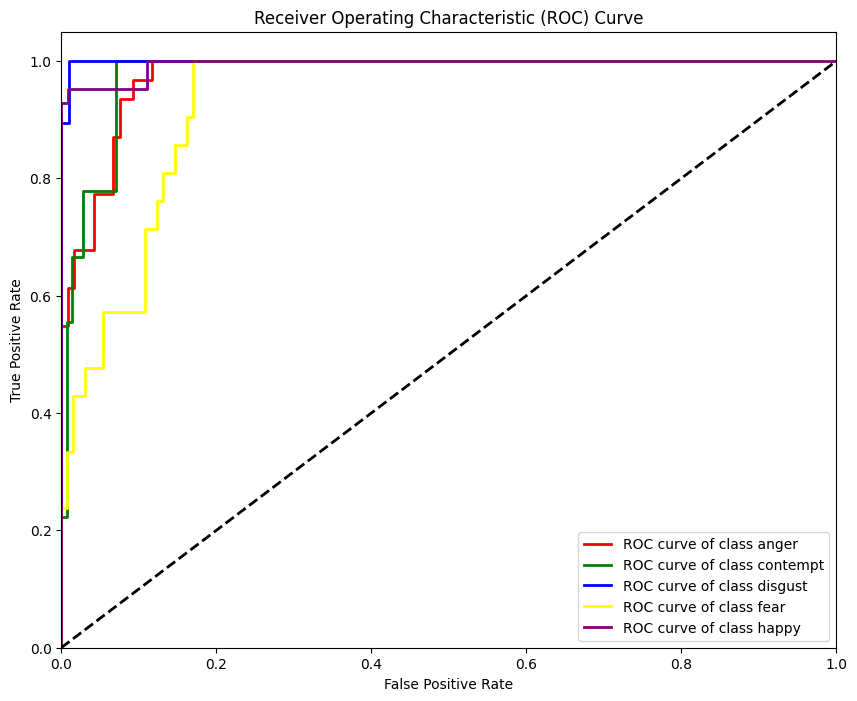

In [ ]:
# The new_class is the correct number of classes
new_class = y_test.shape[1]  # Set new_class to the number of classes in y_test

# Verify the shapes of y_test and y_pred
print("Shape of y_test:", y_test.shape)
print("Shape of y_pred:", y_pred.shape)

# Loop through each class for ROC curve calculation
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(new_class):
    # Class index i does not exceed the number of classes
    if i < y_test.shape[1]:  # If index i is within bounds for y_test and y_pred
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])  # y_test and y_pred should be arrays with shape (num_samples, num_classes)
        roc_auc[i] = auc(fpr[i], tpr[i])

# Colors for the ROC curves
colors = cycle(['red', 'green', 'blue', 'yellow', 'purple', 'orange', 'pink'])

# Plot the ROC curves for each class
plt.figure(figsize=(10, 8))
lw = 2 # Line width for the plot
for i, color in zip(range(new_class), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw, label='ROC curve of class {0}'.format(final_label[i]))

# Plot the diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=lw)

# Set plot limits and labels
plt.xlim([0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')

# Add legend
plt.legend(loc="lower right")

# Show the plot
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


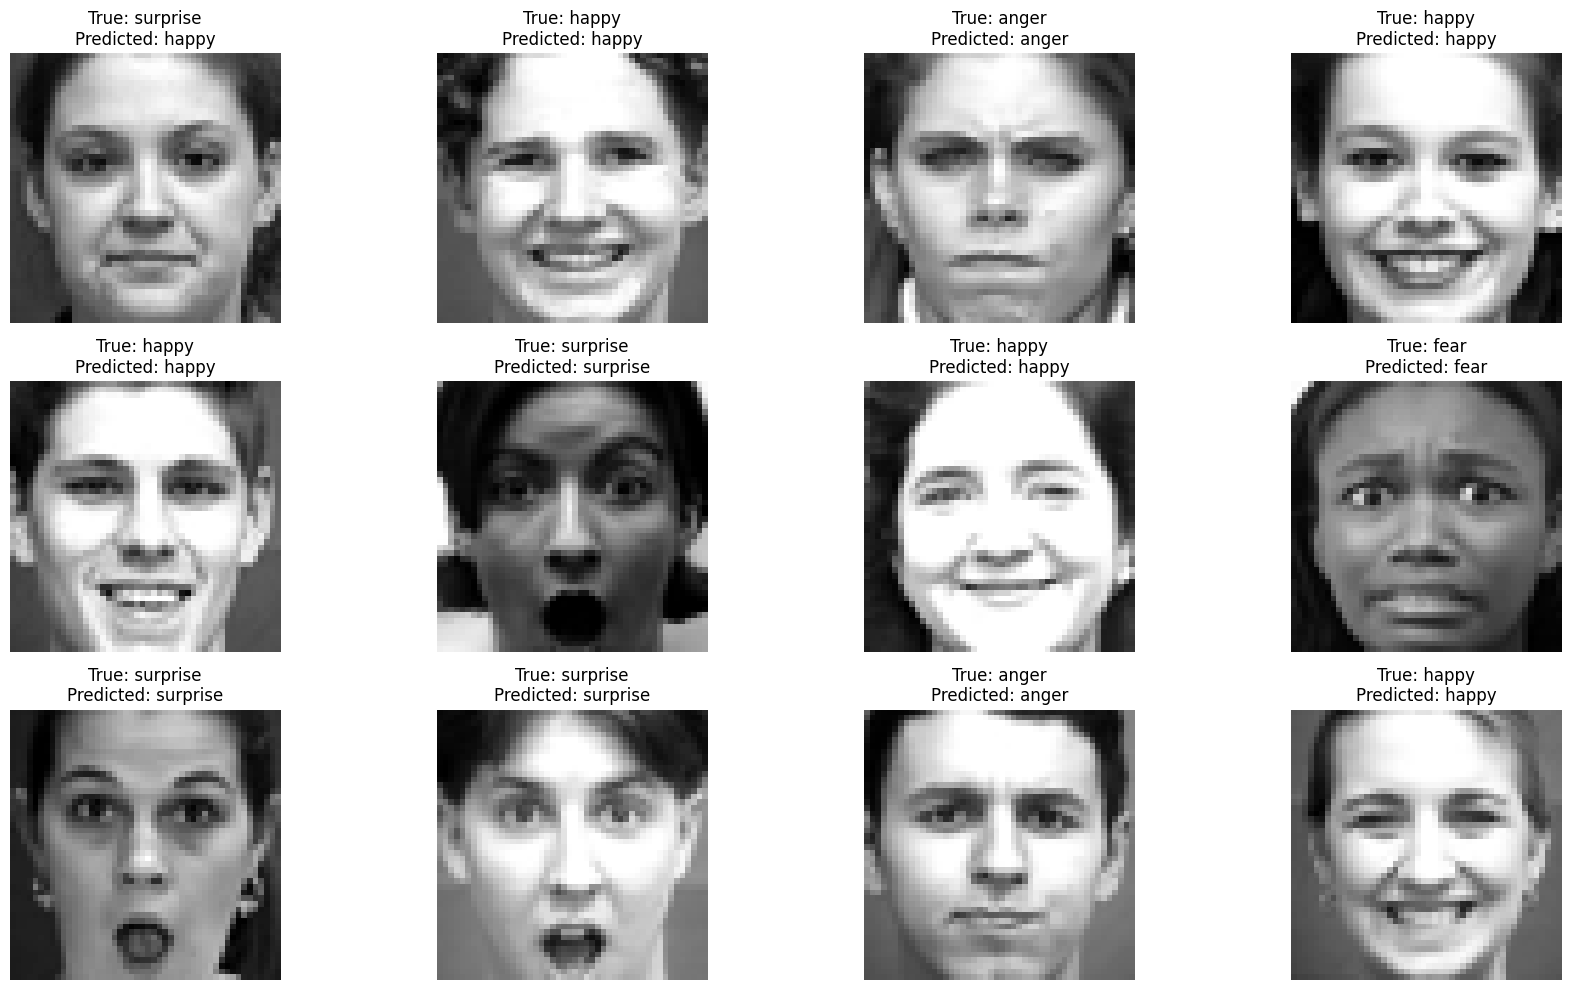

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Class names are defined
class_names = sorted(os.listdir('/content/dataset/CK+48'))

# Number of images to show
num_images = 12

# Image Selection
plt.figure(figsize=(18, 10))
for i in range(num_images):
    img = X_test[i]
    true_label_index = np.argmax(Y_test[i])
    true_label = class_names[true_label_index]

    # Predict
    prediction = model.predict(np.expand_dims(img, axis=0))
    predicted_label_index = np.argmax(prediction)
    predicted_label = class_names[predicted_label_index]

    # Display image
    plt.subplot(3, 4, i + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"True: {true_label}\nPredicted: {predicted_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()


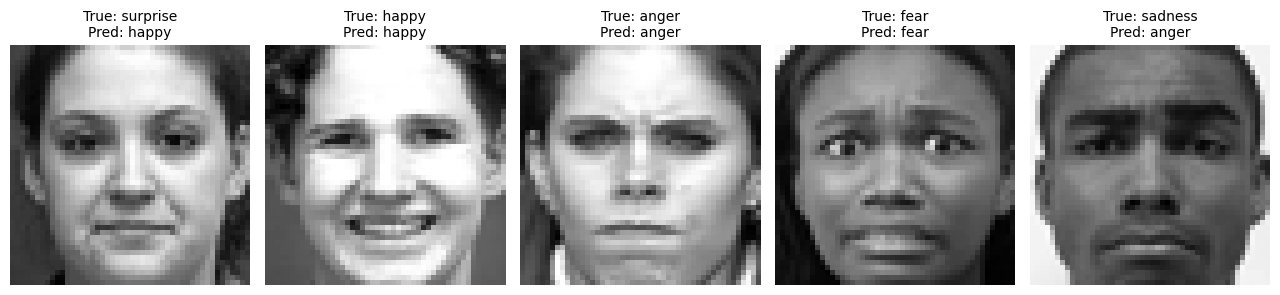

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = sorted(os.listdir('/content/dataset/CK+48'))
shown_classes = set()
images_to_display = []

# Loop through test set and select one image per unique emotion
for i in range(len(X_test)):
    true_class_index = np.argmax(Y_test[i])
    true_class_name = class_names[true_class_index]

    if true_class_name not in shown_classes:
        shown_classes.add(true_class_name)
        img = X_test[i]
        pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
        pred_class = class_names[np.argmax(pred)]
        images_to_display.append((img, true_class_name, pred_class))

    if len(shown_classes) == 7:
        break

# Plot the 7 emotion predictions for 7 different calsses
plt.figure(figsize=(18, 6))
for idx, (img, true_label, predicted_label) in enumerate(images_to_display):
    plt.subplot(1, 7, idx + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"True: {true_label}\nPred: {predicted_label}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()
